In [1]:
import pandas as pd

In [2]:
# We are getting people from wikipedia that from 2020 to 2022 
# had continous pageviews. Some people had a role.

In [3]:
famous_type = 'all'

In [4]:
# df = pd.read_csv("data/clean_localglobal_%s.csv"%famous_type)
# aux = df.groupby('slug')['year'].min().reset_index()
# aux.columns= ['slug','first_wikipedia_year']
# df = df.merge(aux, how='left')
# df.to_csv("data/clean_localglobal_%s.csv"%famous_type, index=False)

In [5]:
df = pd.read_csv("data/13092024/clean_localglobal_%s.csv"%famous_type)
df.head()

,slug,year,n_languages,Global_raw,global,ab,birth,death,occupations,bplace_country,first_wikipedia_year,Volume,Locality_lang,Local_raw,local
0,"""Weird_Al""_Yankovic",2015,32,0.096970,0.173184,NaN,1959.0,NaN,SINGER,United States,2015,685999.0,en,0.786811,0.686553
1,"""Weird_Al""_Yankovic",2016,31,0.093939,0.165746,NaN,1959.0,NaN,SINGER,United States,2015,1984716.0,en,0.790601,0.682772
2,"""Weird_Al""_Yankovic",2017,35,0.106061,0.175258,NaN,1959.0,NaN,SINGER,United States,2015,1753975.0,en,0.825261,0.732815
3,"""Weird_Al""_Yankovic",2018,37,0.112121,0.174757,NaN,1959.0,NaN,SINGER,United States,2015,1716270.0,en,0.821383,0.725058
4,"""Weird_Al""_Yankovic",2019,38,0.115152,0.172093,NaN,1959.0,NaN,SINGER,United States,2015,1846256.0,en,0.804583,0.715257


In [8]:
df[df['death'].isna()]['slug'].nunique()

27705

In [6]:
df[df['death']<=2024]['slug'].nunique()

23760

In [7]:
df[df['death']<=2015]['slug'].nunique()

22372

In [104]:
df[df['slug']=='Elinor_Ostrom']

,slug,year,n_languages,Global_raw,global,ab,birth,death,occupations,bplace_country,first_wikipedia_year,Volume,Locality_lang,Local_raw,local
151121,Elinor_Ostrom,2015,48,0.145455,0.262570,NaN,1933.0,2012.0,ECONOMIST,United States,2015,121908.0,en,0.647313,0.481453
151122,Elinor_Ostrom,2016,50,0.151515,0.270718,NaN,1933.0,2012.0,ECONOMIST,United States,2015,276551.0,en,0.647417,0.465856
151123,Elinor_Ostrom,2017,54,0.163636,0.273196,NaN,1933.0,2012.0,ECONOMIST,United States,2015,262563.0,en,0.675504,0.503828
151124,Elinor_Ostrom,2018,56,0.169697,0.266990,NaN,1933.0,2012.0,ECONOMIST,United States,2015,299168.0,en,0.678594,0.505265
151125,Elinor_Ostrom,2019,56,0.169697,0.255814,NaN,1933.0,2012.0,ECONOMIST,United States,2015,328675.0,en,0.672253,0.522438
151126,Elinor_Ostrom,2020,61,0.184848,0.298507,NaN,1933.0,2012.0,ECONOMIST,United States,2015,344835.0,en,0.621759,0.457193
151127,Elinor_Ostrom,2021,66,0.200000,0.321782,NaN,1933.0,2012.0,ECONOMIST,United States,2015,339466.0,en,0.622717,0.449698
151128,Elinor_Ostrom,2022,67,0.203030,0.320388,NaN,1933.0,2012.0,ECONOMIST,United States,2015,321652.0,en,0.633427,0.467389
151129,Elinor_Ostrom,2023,67,0.203030,0.265060,NaN,1933.0,2012.0,ECONOMIST,United States,2015,321768.0,en,0.664132,0.503701
151130,Elinor_Ostrom,2024,68,0.206061,0.231834,NaN,1933.0,2012.0,ECONOMIST,United States,2015,184793.0,en,0.655349,0.509005


In [90]:
df[df['year']==2022][['local','global']].corr(method='spearman')

,local,global
local,1.000000,0.177909
global,0.177909,1.000000


In [91]:
def get_limits_bycountry(sample_, qmin, qmax):
    get_limits = []
    for question_bplace_country in sample_[sample_['bplace_country'].notna()]['bplace_country'].unique():
        
        min_limit = None
        max_limit = None
        try:
            
            min_limit = np.quantile(sample_[(sample_['bplace_country']==question_bplace_country)][['slug','local']]\
                            .drop_duplicates().dropna()['local'].dropna(), q=qmin)
            
            max_limit = np.quantile(sample_[(sample_['bplace_country']==question_bplace_country)][['slug','local']]\
                            .drop_duplicates().dropna()['local'].dropna(), q=qmax)
            
            get_limits.append([question_bplace_country, min_limit, max_limit])
            
        except:
            continue
        
    return get_limits

In [92]:
sdf = df[df['year']==2022].copy()

sdf['globality'] = None
import numpy as np
limts = np.quantile(sdf[['slug','global']].drop_duplicates().dropna()['global'].dropna(), q=0.8)
sdf.loc[sdf['global']>=limts, 'globality'] = 'High globality'
print(limts)

limts = np.quantile(sdf[['slug','global']].drop_duplicates().dropna()['global'].dropna(), q=0.2)
sdf.loc[(sdf['global']<limts), 'globality'] = 'Low globality'
print(limts)

0.0922330097087378
0.029126213592233


In [93]:
sdf.head(2)

,slug,year,n_languages,Global_raw,global,ab,birth,death,occupations,bplace_country,first_wikipedia_year,Volume,Locality_lang,Local_raw,local,globality
7,"""Weird_Al""_Yankovic",2022,25,0.075758,0.116505,NaN,1959.0,NaN,SINGER,United States,2015,4824130.0,en,0.816171,0.732906,High globality
17,'Abd_Allah_ibn_'Amr_ibn_al-'As,2022,15,0.045455,0.067961,NaN,616.0,684.0,RELIGIOUS FIGURE,Saudi Arabia,2015,95879.0,ar,0.724623,0.599891,None


In [94]:
get_limits = get_limits_bycountry(sdf, qmin=0.2, qmax=0.8)
both_limts = pd.DataFrame(get_limits, columns=['bplace_country','min','max'])
sdf = sdf.merge(both_limts, how='left', on='bplace_country')

In [95]:
sdf['locality'] = None
sdf.loc[sdf['local']>=sdf['max'], 'locality'] = 'High locality'
sdf.loc[sdf['local']<sdf['min'], 'locality'] = 'Low locality'
# sample_ = sample_[sample_['person_country'].notna()]

In [96]:
sdf['globality'].value_counts()

High globality    11064
Low globality      9698
Name: globality, dtype: int64

In [97]:
sdf['locality'].value_counts()

High locality    8990
Low locality     8927
Name: locality, dtype: int64

In [98]:
from scipy import stats
ab = sdf.copy()
r_squared = stats.linregress(x=ab['global'], y=ab['local']).rvalue ** 2
r_squared, ab[['local','global']].corr(method='pearson'), ab[['local','global']].corr(method='spearman')          

(0.05825032421163076,
            local    global
 local   1.000000  0.241351
 global  0.241351  1.000000,
            local    global
 local   1.000000  0.177909
 global  0.177909  1.000000)

In [99]:
from scipy import stats
ab = sdf[sdf['locality']=='High locality']
r_squared = stats.linregress(x=ab['global'], y=ab['local']).rvalue ** 2
r_squared, ab[['local','global']].corr(method='pearson'), ab[['local','global']].corr(method='spearman')          

(0.0030382334348035673,
           local   global
 local   1.00000  0.05512
 global  0.05512  1.00000,
            local    global
 local   1.000000 -0.009367
 global -0.009367  1.000000)

In [100]:
from scipy import stats
ab = sdf[sdf['locality']=='Low locality']
r_squared = stats.linregress(x=ab['global'], y=ab['local']).rvalue ** 2
r_squared, ab[['local','global']].corr(method='pearson'), ab[['local','global']].corr(method='spearman')          

(0.1488542137294273,
            local    global
 local   1.000000  0.385816
 global  0.385816  1.000000,
            local    global
 local   1.000000  0.433942
 global  0.433942  1.000000)

In [101]:
from scipy import stats
ab = sdf[sdf['globality']=='High globality']
r_squared = stats.linregress(x=ab['global'], y=ab['local']).rvalue ** 2
r_squared, ab[['local','global']].corr(method='pearson'), ab[['local','global']].corr(method='spearman')          

(0.07695955539902305,
            local    global
 local   1.000000  0.277416
 global  0.277416  1.000000,
            local    global
 local   1.000000  0.277104
 global  0.277104  1.000000)

In [102]:
from scipy import stats
ab = sdf[sdf['globality']=='Low globality']
r_squared = stats.linregress(x=ab['global'], y=ab['local']).rvalue ** 2
r_squared, ab[['local','global']].corr(method='pearson'), ab[['local','global']].corr(method='spearman')          


(0.11314754113210804,
            local    global
 local   1.000000  0.336374
 global  0.336374  1.000000,
            local    global
 local   1.000000  0.321122
 global  0.321122  1.000000)

In [103]:
from scipy import stats
ab = sdf[ sdf['globality']=='Low globality']
r_squared = stats.linregress(x=ab['global'], y=ab['local']).rvalue ** 2
r_squared          

0.11314754113210804

In [25]:
aux = df[['slug','death']].drop_duplicates()
aux[aux['death']<2015]

,slug,death
10,'Abd_Allah_ibn_'Amr_ibn_al-'As,684.0
20,'Abd_Allah_ibn_Rawahah,629.0
30,'Abd_al-Rahman_ibn_'Awf,654.0
40,'Adud_al-Dawla,983.0
50,10th_Dalai_Lama,1837.0
...,...,...
486994,Žemaitė,1921.0
487004,Živojin_Mišić,1921.0
487024,Ștefan_Barbu,1970.0
487034,Ștefan_Golescu,1874.0


In [16]:
26618 + 21852 

48470

In [11]:
df[['slug','occupations']].drop_duplicates()['occupations'].value_counts().head(30)

POLITICIAN            5349
WRITER                2432
ACTOR                 1279
RELIGIOUS FIGURE       914
SOCCER PLAYER          902
MILITARY PERSONNEL     837
PAINTER                744
COMPOSER               624
PHILOSOPHER            471
ATHLETE                461
MUSICIAN               457
BIOLOGIST              438
SINGER                 360
MATHEMATICIAN          341
NOBLEMAN               326
FILM DIRECTOR          290
ACADEMIC               286
PHYSICIST              281
COMPANION              280
ASTRONOMER             279
ARCHITECT              260
MEDICAL DOCTOR         250
CHEMIST                234
BUSINESSPERSON         206
ENGINEER               199
HISTORIAN              196
EXPLORER               194
RACING DRIVER          180
SOCIAL ACTIVIST        159
INVENTOR               153
Name: occupations, dtype: int64

In [16]:
all_ = df[['slug','bplace_country','occupations']].drop_duplicates()['occupations'].value_counts(normalize=False)
all_ = all_.reset_index()
# all_[all_['index']=='SOCCER PLAYER']
# 
all_.head(30)


,index,occupations
0,SOCCER PLAYER,9040
1,POLITICIAN,7864
2,ACTOR,5308
3,WRITER,3513
4,ATHLETE,2100
5,SINGER,2097
6,MUSICIAN,1501
7,RELIGIOUS FIGURE,1253
8,MILITARY PERSONNEL,938
9,COMPOSER,816


In [17]:
all_ = df[['slug','bplace_country','occupations']].drop_duplicates()

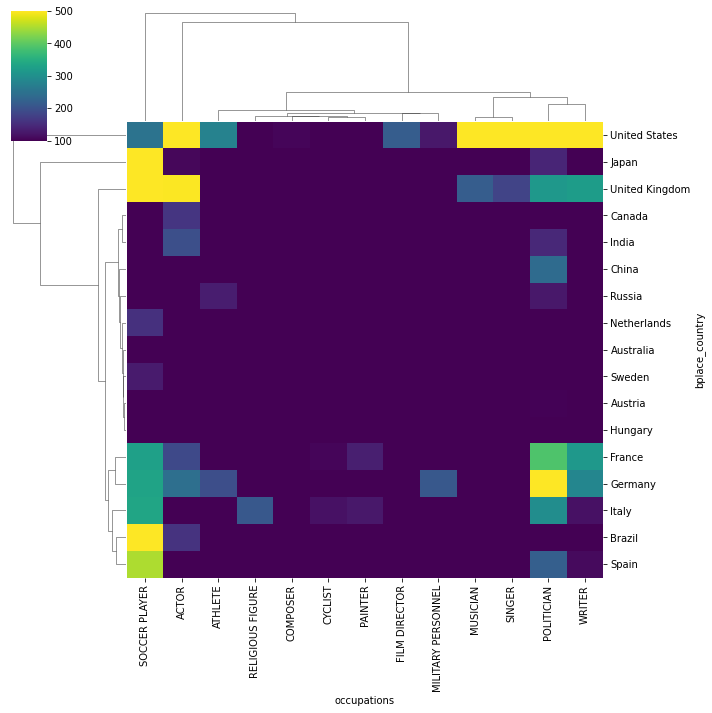

In [18]:
import numpy as np
matrix_geo = all_.pivot_table(index='bplace_country',\
                 columns='occupations',\
                 values='slug', aggfunc=pd.Series.nunique)
aux = matrix_geo.sum(axis=1).reset_index()
cols = aux[aux[0]>500]['bplace_country'].unique()
matrix_geo = matrix_geo.T[cols].T

aux = matrix_geo.sum(axis=0).reset_index()
cols = aux[aux[0]>500]['occupations'].unique()
matrix_geo = matrix_geo[cols].fillna(0)

import seaborn as sns
sns.clustermap(matrix_geo, cmap='viridis', vmin=100, vmax=500)
# matrix_geo

In [19]:
including_ = [ 
    # 'Ada_Lovelace','Claude_Monet', 'Anawrahta',\
            # 'Donald_Trump' ,\
               'Napoleon','Bernardo_OHiggins', \
              # 'Victor_Hugo', 'Albert_Einstein', \
              "Johnny_Unitas","Elinor_Ostrom",
              # 'Nina_Høiberg' ,  
    # 'Jean_Dausset', 'Michael_Jackson' 
]

In [20]:
df.head(2)

,slug,year,n_languages,Global_raw,global,ab,birth,death,occupations,bplace_country,first_wikipedia_year,Volume,Locality_lang,Local_raw,local
0,"""Weird_Al""_Yankovic",2015,32,0.096970,0.173184,NaN,1959.0,NaN,SINGER,United States,2015,685999.0,en,0.786811,0.686553
1,"""Weird_Al""_Yankovic",2016,31,0.093939,0.165746,NaN,1959.0,NaN,SINGER,United States,2015,1984716.0,en,0.790601,0.682772


In [21]:
to_p = df.melt(id_vars=['slug','year'], value_vars=['local','global'])
to_p['slug'] = to_p['slug'].apply(str).str.replace("_", " ")
to_p.columns = ['Historical figure','year','Fame','value']
to_p.sample(3)

,Historical figure,year,Fame,value
889141,Raúl Páez,2021,global,0.054455
111259,Christopher Cross,2017,local,0.614118
527724,Andrea Berg,2022,global,0.029126


(0.0, 1.0)

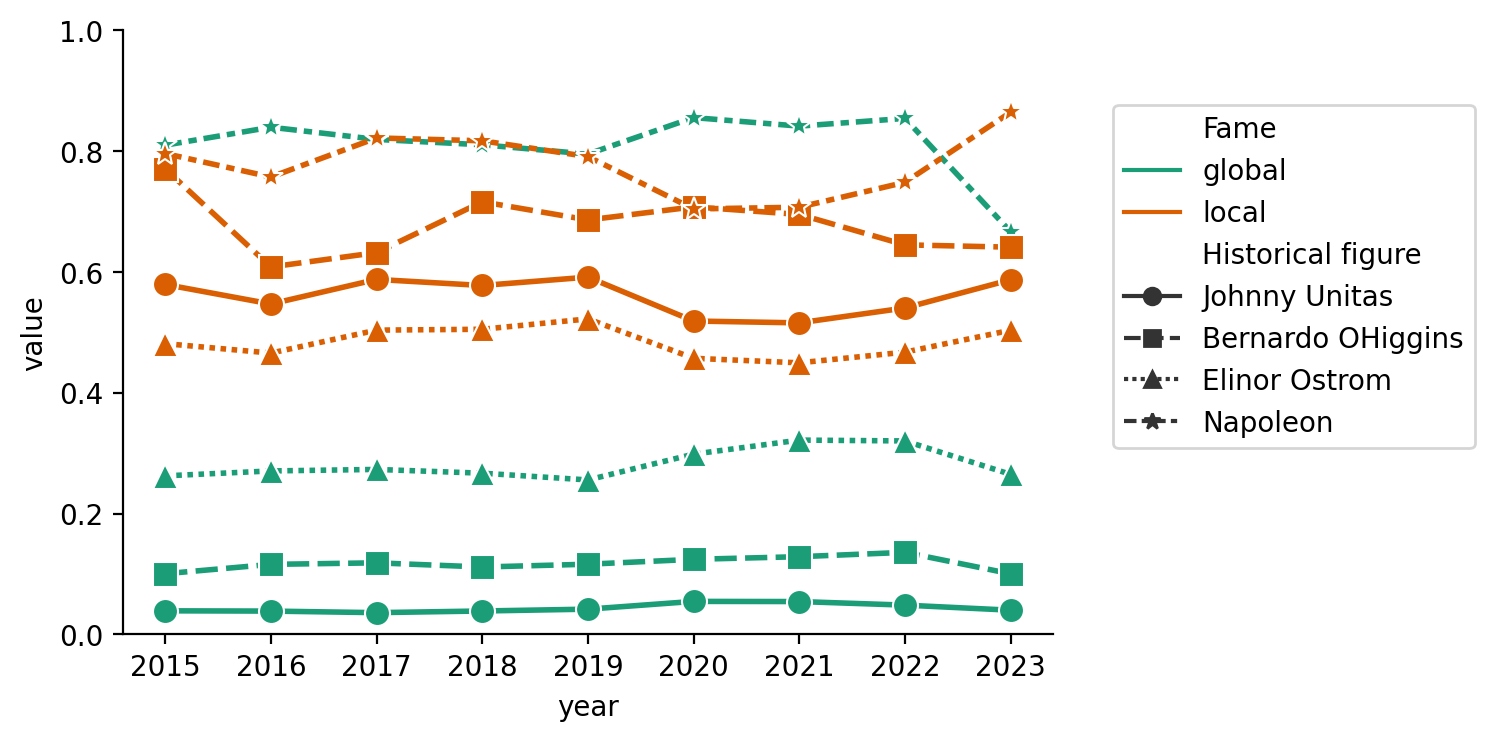

In [22]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(dpi=200)
including_ = [  'Napoleon','Bernardo OHiggins', "Johnny Unitas","Elinor Ostrom",]

sns.lineplot(data = to_p[(to_p['Historical figure'].isin(including_)) & (to_p['year']<2024)].sort_values(by='value'), x='year', y='value',
             style='Historical figure', linewidth=2,  markers=['o','s','^','*'], alpha=1, hue='Fame', markersize=9, palette='Dark2')
plt.legend(bbox_to_anchor=(1.05, 0.9))
ax.spines[['right', 'top']].set_visible(False)
plt.ylim(0,1)

(0.0, 1.0)

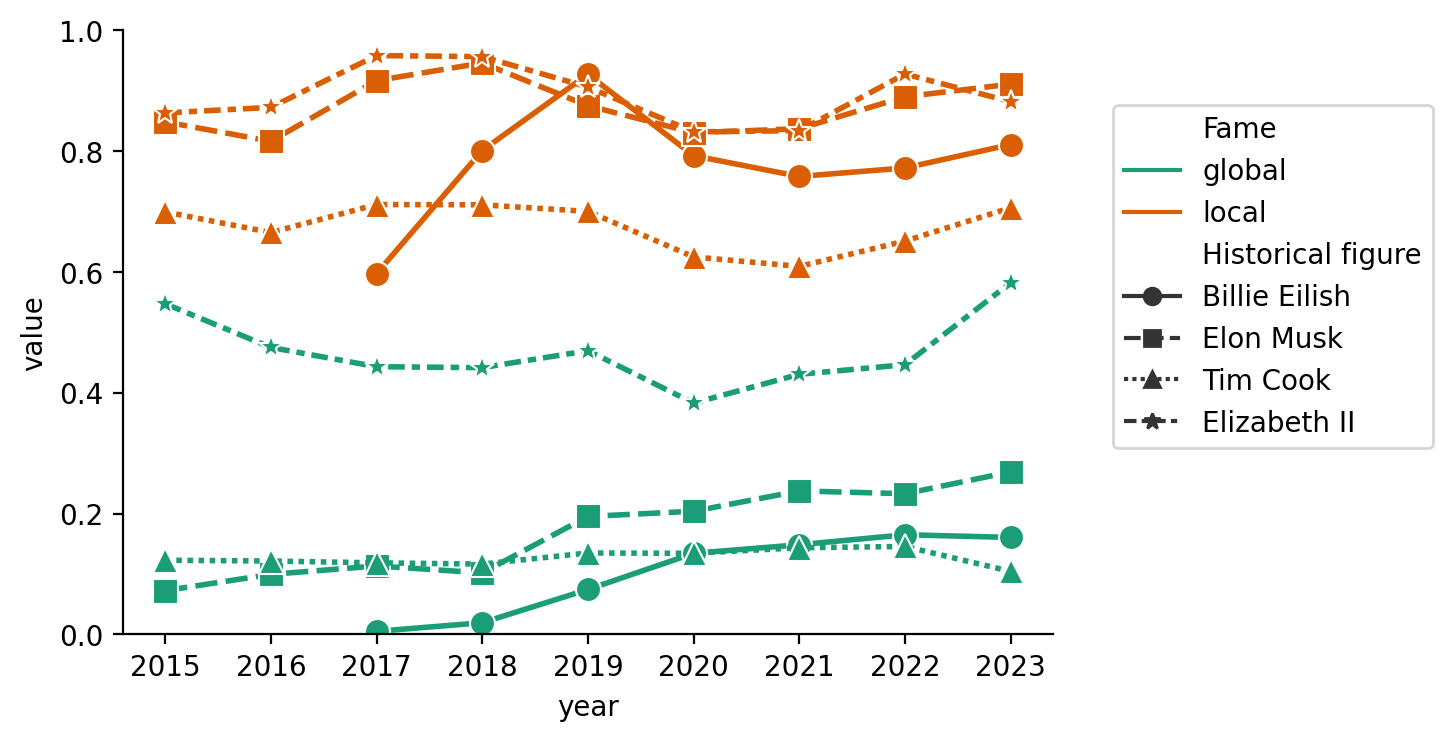

In [30]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(dpi=200)
including_ = [  'Tim Cook', "Elon Musk","Billie Eilish","Elizabeth II"]

sns.lineplot(data = to_p[(to_p['Historical figure'].isin(including_)) & (to_p['year']<=2023)].sort_values(by='value'), x='year', y='value',
             style='Historical figure', linewidth=2,  markers=['o','s','^','*'], alpha=1, hue='Fame', markersize=9, palette='Dark2')
plt.legend(bbox_to_anchor=(1.05, 0.9))
ax.spines[['right', 'top']].set_visible(False)
plt.ylim(0,1)

In [31]:
occupations_year = df[['year','bplace_country','occupations','slug']].drop_duplicates().groupby(['year','bplace_country'])['occupations'].value_counts(normalize=True).reset_index(name='percentage')


,year,bplace_country,occupations,percentage
0,2015,Afghanistan,POLITICIAN,0.709677
1,2015,Afghanistan,ACADEMIC,0.032258
2,2015,Afghanistan,BUSINESSPERSON,0.032258
3,2015,Afghanistan,CELEBRITY,0.032258
4,2015,Afghanistan,GEOGRAPHER,0.032258


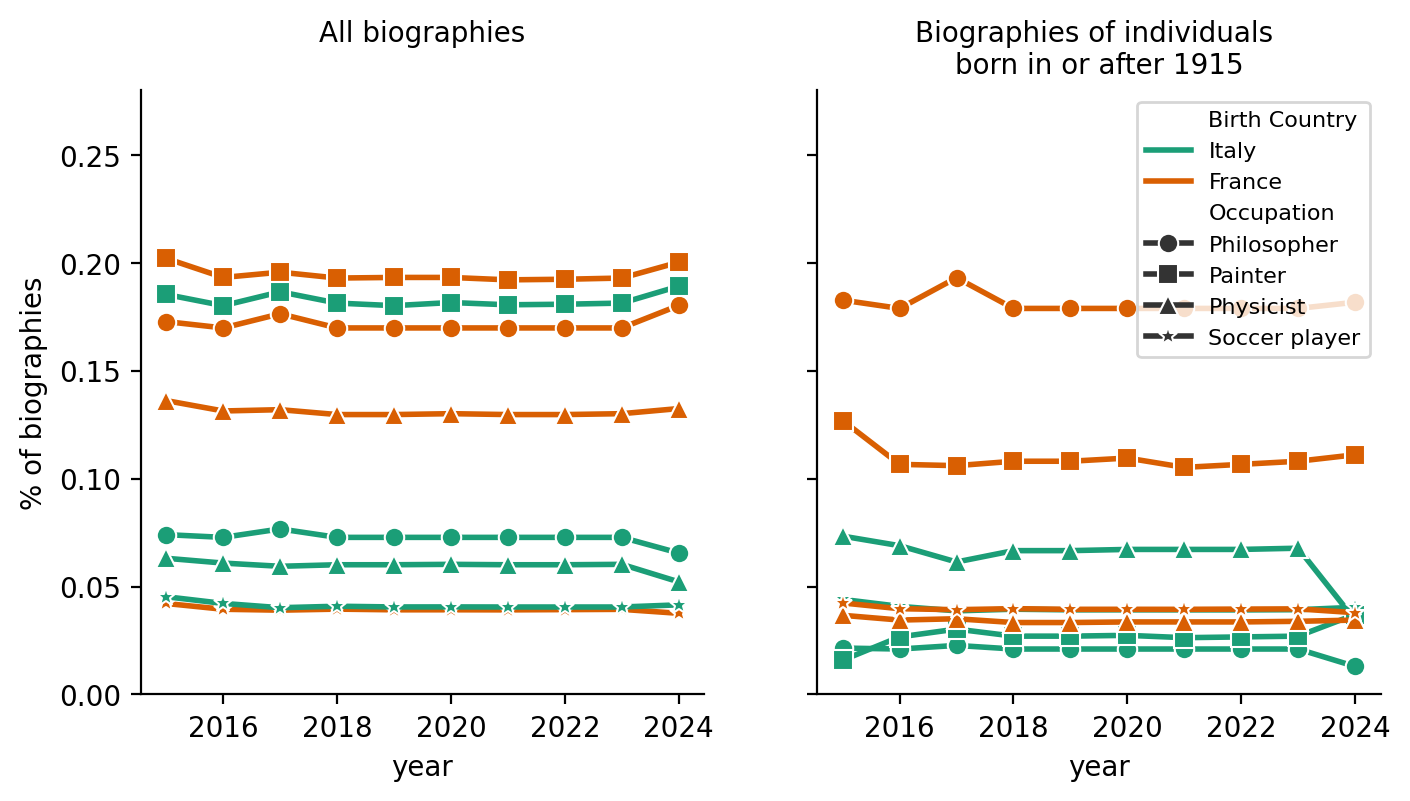

In [101]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(ncols=2, dpi=200, figsize=(8,4), sharey=True)
including_ = [  'France', "Italy"]
# ,"United States","Brazil"
including_occ = [ 'Soccer player',"Painter","Philosopher","Physicist"]
makers ={
         'Soccer player':'*',"Painter":'s',"Philosopher":'o',"Physicist":'^'
}
colorsc ={
         'Italy':'#1B9E77',"France":'#D95F02'
}

import seaborn as sns
country_year = df[['year','bplace_country','occupations','slug']].drop_duplicates().groupby(['year','occupations'])['bplace_country'].value_counts(normalize=True).reset_index(name='percentage')
country_year['occupations'] = country_year['occupations'].str.capitalize()
country_year.rename(columns={'percentage':'% of biographies','bplace_country':'Birth Country', 'occupations':'Occupation'}, inplace=True)
sns.lineplot(data = country_year[(country_year['Birth Country'].isin(including_)) & \
             (country_year['Occupation'].isin(including_occ))].sort_values(by='% of biographies'), x='year', y='% of biographies',
             style='Occupation', linewidth=2,  markers=makers, alpha=1, hue='Birth Country',  dashes=False, legend=False, markersize=7, palette=colorsc, ax=ax[0])

country_year = df[df['birth']>=1915][['year','bplace_country','occupations','slug']].drop_duplicates().groupby(['year','occupations'])['bplace_country'].value_counts(normalize=True).reset_index(name='percentage')
country_year['occupations'] = country_year['occupations'].str.capitalize()
country_year.rename(columns={'percentage':'% of biographies','bplace_country':'Birth Country', 'occupations':'Occupation'}, inplace=True)
sns.lineplot(data = country_year[(country_year['Birth Country'].isin(including_)) & \
             (country_year['Occupation'].isin(including_occ))].sort_values(by='% of biographies'), x='year', y='% of biographies',
             style='Occupation', linewidth=2,  markers=makers, alpha=1,  dashes=False, hue='Birth Country', markersize=7, palette=colorsc, ax=ax[1])
# bbox_to_anchor=(1.05, 0.9)
ax[1].legend(fontsize=8)
ax[0].spines[['right', 'top']].set_visible(False)
ax[0].set_ylim(0,0.28)
ax[0].set_title('All biographies\n', fontsize=10)
ax[1].set_title('Biographies of individuals \nborn in or after 1915', fontsize=10)
ax[1].spines[['right', 'top']].set_visible(False)
ax[1].set_ylim(0,0.28)
plt.savefig("distribution_time.svg")

In [102]:
country_year = df[['year','bplace_country','occupations','slug']].drop_duplicates().groupby(['year','occupations'])['bplace_country'].value_counts(normalize=True).reset_index(name='percentage')
country_year['occupations'] = country_year['occupations'].str.capitalize()
country_year.rename(columns={'percentage':'% of biographies','bplace_country':'Birth Country', 'occupations':'Occupation'}, inplace=True)

In [103]:
country_year[(country_year['year']==2022) & (country_year['Occupation']=="Painter") & (country_year['Birth Country']=="France")]

,year,Occupation,Birth Country,% of biographies
25260,2022,Painter,France,0.192475


In [104]:
country_year[(country_year['year']==2015) & (country_year['Occupation']=="Painter") & (country_year['Birth Country']=="France")]

,year,Occupation,Birth Country,% of biographies
1839,2015,Painter,France,0.202128


In [105]:
country_year = df[df['birth']>=1915][['year','bplace_country','occupations','slug']].drop_duplicates().groupby(['year','occupations'])['bplace_country'].value_counts(normalize=True).reset_index(name='percentage')
country_year['occupations'] = country_year['occupations'].str.capitalize()
country_year.rename(columns={'percentage':'% of biographies','bplace_country':'Birth Country', 'occupations':'Occupation'}, inplace=True)


In [106]:
country_year[(country_year['year']==2022) & (country_year['Occupation']=="Painter") & (country_year['Birth Country']=="France")]

,year,Occupation,Birth Country,% of biographies
20579,2022,Painter,France,0.106667


In [107]:
country_year[(country_year['year']==2015) & (country_year['Occupation']=="Painter") & (country_year['Birth Country']=="France")]

,year,Occupation,Birth Country,% of biographies
1435,2015,Painter,France,0.126984


<ipython-input-55-61596f1ab680>:7: UserWarning: The markers list has more values (4) than needed (3), which may not be intended.
  sns.lineplot(data = occupations_year[(occupations_year['bplace_country'].isin(including_)) & \


(0.0, 0.1)

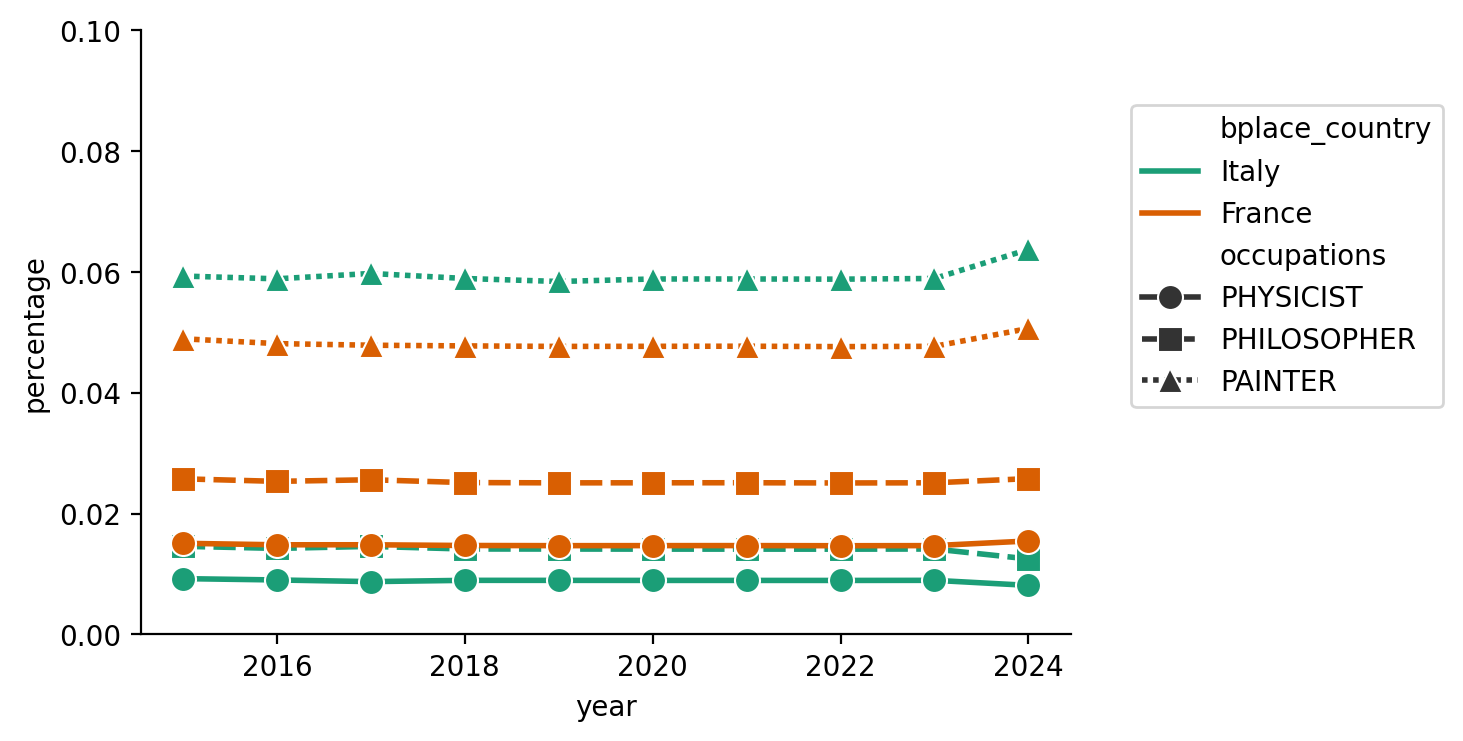

In [55]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(dpi=200)
including_ = [  'France', "Italy"]
# ,"United States","Brazil"'SOCCER PLAYER',
including_occ = [   "PAINTER","PHILOSOPHER","PHYSICIST"]
import seaborn as sns
sns.lineplot(data = occupations_year[(occupations_year['bplace_country'].isin(including_)) & \
             (occupations_year['occupations'].isin(including_occ))].sort_values(by='percentage'), x='year', y='percentage',
             style='occupations', linewidth=2,  markers=['o','s','^','*'], alpha=1, hue='bplace_country', markersize=9, palette='Dark2')
plt.legend(bbox_to_anchor=(1.05, 0.9))
ax.spines[['right', 'top']].set_visible(False)
plt.ylim(0,0.10)

In [28]:
df[(df['occupations']=='SOCCER PLAYER')][['slug','bplace_country']].drop_duplicates()\
        ['bplace_country'].value_counts(normalize=True)*100

Japan                       25.347373
United Kingdom               7.121146
Brazil                       6.969171
Spain                        5.416848
Germany                      4.201042
                              ...    
San Marino                   0.010855
Belize                       0.010855
Central African Republic     0.010855
Syria                        0.010855
Nicaragua                    0.010855
Name: bplace_country, Length: 152, dtype: float64

In [33]:
df[(df['bplace_country']=='France')][['slug','occupations']].drop_duplicates()\
        ['occupations'].value_counts(normalize=False).head(20)

POLITICIAN            414
SOCCER PLAYER         369
WRITER                338
ACTOR                 223
PAINTER               139
CYCLIST               106
FILM DIRECTOR         100
COMPOSER               97
PHILOSOPHER            79
RELIGIOUS FIGURE       79
BIOLOGIST              73
SINGER                 70
MATHEMATICIAN          66
MILITARY PERSONNEL     65
ATHLETE                57
NOBLEMAN               55
MUSICIAN               46
PHYSICIST              41
RACING DRIVER          37
CHEMIST                33
Name: occupations, dtype: int64

In [32]:
df[(df['bplace_country']=='France')][['slug','occupations']].drop_duplicates()\
        ['occupations'].value_counts(normalize=True).head(20)*100

POLITICIAN            13.551555
SOCCER PLAYER         12.078560
WRITER                11.063830
ACTOR                  7.299509
PAINTER                4.549918
CYCLIST                3.469722
FILM DIRECTOR          3.273322
COMPOSER               3.175123
PHILOSOPHER            2.585925
RELIGIOUS FIGURE       2.585925
BIOLOGIST              2.389525
SINGER                 2.291326
MATHEMATICIAN          2.160393
MILITARY PERSONNEL     2.127660
ATHLETE                1.865794
NOBLEMAN               1.800327
MUSICIAN               1.505728
PHYSICIST              1.342062
RACING DRIVER          1.211129
CHEMIST                1.080196
Name: occupations, dtype: float64

In [9]:
painters = (df[df['occupations']=='PAINTER'][['slug','bplace_country','occupations']].drop_duplicates()\
        ['bplace_country'].value_counts(normalize=True).sort_values(ascending=False).head(15)*100).reset_index()
print(painters.set_index('bplace_country').to_latex())

\begin{tabular}{lr}
\toprule
 & proportion \\
bplace_country &  \\
\midrule
France & 19.219653 \\
Italy & 18.063584 \\
Netherlands & 8.959538 \\
United States & 8.381503 \\
Germany & 7.803468 \\
United Kingdom & 5.780347 \\
Russia & 3.757225 \\
Spain & 2.601156 \\
China & 2.023121 \\
Switzerland & 1.878613 \\
Denmark & 1.734104 \\
Austria & 1.589595 \\
Belgium & 1.445087 \\
Sweden & 1.300578 \\
Japan & 1.300578 \\
\bottomrule
\end{tabular}



In [10]:
df[df['occupations']=='SOCCER PLAYER'][['slug','bplace_country','occupations']].drop_duplicates()\
        ['bplace_country'].value_counts(normalize=True).sort_values(ascending=False)

bplace_country
Japan             0.276687
Brazil            0.072044
United Kingdom    0.063667
Spain             0.053854
Italy             0.040091
                    ...   
Hong Kong         0.000120
Laos              0.000120
Afghanistan       0.000120
Namibia           0.000120
Nicaragua         0.000120
Name: proportion, Length: 150, dtype: float64

In [11]:
df[df['occupations']=='POLITICIAN'][['slug','bplace_country','occupations']].drop_duplicates()\
        ['bplace_country'].value_counts(normalize=True).sort_values(ascending=False).head(10)



bplace_country
United States     0.096443
Germany           0.082530
France            0.061344
United Kingdom    0.049328
Italy             0.046324
China             0.037628
Spain             0.034625
Turkey            0.027510
Egypt             0.026561
Greece            0.024190
Name: proportion, dtype: float64

In [12]:
df[df['bplace_country']=='France'][['slug','bplace_country','occupations']].drop_duplicates()\
        ['occupations'].value_counts(normalize=True).head(20)



occupations
POLITICIAN            0.138919
SOCCER PLAYER         0.116362
WRITER                0.112066
ACTOR                 0.067669
PAINTER               0.047619
CYCLIST               0.037594
COMPOSER              0.031149
FILM DIRECTOR         0.029717
RELIGIOUS FIGURE      0.028285
BIOLOGIST             0.025421
PHILOSOPHER           0.025063
MILITARY PERSONNEL    0.022914
MATHEMATICIAN         0.020766
SINGER                0.020408
ATHLETE               0.019334
NOBLEMAN              0.018976
MUSICIAN              0.015038
PHYSICIST             0.014680
RACING DRIVER         0.012531
TENNIS PLAYER         0.011099
Name: proportion, dtype: float64

In [13]:
df[['slug','bplace_country']].drop_duplicates()['bplace_country'].value_counts(normalize=True)

bplace_country
United States                  0.206623
Germany                        0.086531
United Kingdom                 0.077295
Japan                          0.068837
France                         0.062161
                                 ...   
Kingdom of the Two Sicilies    0.000022
East Timor                     0.000022
Byzantine Empire               0.000022
Bermuda                        0.000022
Wey                            0.000022
Name: proportion, Length: 227, dtype: float64

In [14]:
df[['slug','bplace_country']].drop_duplicates()['bplace_country'].value_counts()

bplace_country
United States                  9284
Germany                        3888
United Kingdom                 3473
Japan                          3093
France                         2793
                               ... 
Kingdom of the Two Sicilies       1
East Timor                        1
Byzantine Empire                  1
Bermuda                           1
Wey                               1
Name: count, Length: 227, dtype: int64

In [15]:
df[(df['slug'].str.contains('Elinor_Ostrom')) &\
(df['year']==2022)]

,slug,year,n_languages,Global_raw,global,ab,birth,death,occupations,bplace_country,first_wikipedia_year,Volume,Locality_lang,Local_raw,local
151128,Elinor_Ostrom,2022,67,0.20303,0.320388,NaN,1933.0,2012.0,ECONOMIST,United States,2015,321652.0,en,0.633427,0.467389


In [16]:
df[(df['slug'].str.contains('Johnny_Unitas')) &\
(df['year']==2022)]

,slug,year,n_languages,Global_raw,global,ab,birth,death,occupations,bplace_country,first_wikipedia_year,Volume,Locality_lang,Local_raw,local
255544,Johnny_Unitas,2022,11,0.033333,0.048544,NaN,1933.0,2002.0,ACTOR,United States,2015,374660.0,en,0.683766,0.540529


In [17]:
df[df['slug'].str.contains('Nelson_Mandela')]

,slug,year,n_languages,Global_raw,global,ab,birth,death,occupations,bplace_country,first_wikipedia_year,Volume,Locality_lang,Local_raw,local


In [18]:
df[df['slug'].str.contains('Marie_Curie')]

,slug,year,n_languages,Global_raw,global,ab,birth,death,occupations,bplace_country,first_wikipedia_year,Volume,Locality_lang,Local_raw,local


In [19]:
dead_people = df[(df['birth']<2015) & 
             (df['death']<2015)]['slug'].unique()
print(len(dead_people))

21852


In [35]:
21852+26618

48470

In [20]:
alive_people = df[ (df['birth']>=1915) &  
             (df['death'].isna())]['slug'].unique()
print(len(alive_people))

26618


In [25]:
import numpy as np
tog = np.hstack([dead_people,alive_people])

In [34]:
df[df['slug'].isin(tog)][['birth','death']]

,birth,death
0,1959.0,NaN
1,1959.0,NaN
2,1959.0,NaN
3,1959.0,NaN
4,1959.0,NaN
...,...,...
487077,-1267.0,-1300.0
487078,-1267.0,-1300.0
487079,-1267.0,-1300.0
487080,-1267.0,-1300.0


In [37]:
df['alive_dead'] = None
df.loc[df['slug'].isin(alive_people),'alive_dead'] = 'Alive'
df.loc[df['slug'].isin(dead_people),'alive_dead'] = 'Dead'
df.loc[df['slug'].isna(),'alive_dead'] = None
df.groupby('year')['alive_dead'].value_counts()

year  alive_dead
2015  Dead          20424
2016  Dead          21531
2017  Dead          20955
2018  Dead          21553
2019  Dead          21601
2020  Dead          21627
2021  Dead          21685
2022  Dead          21644
2023  Dead          21576
2024  Dead          16075
Name: alive_dead, dtype: int64

In [38]:
df.groupby('first_wikipedia_year')['slug'].nunique()

first_wikipedia_year
2015    21790
2016       19
2017       16
2018       22
2019        5
Name: slug, dtype: int64

In [39]:
df['rank'] = df.groupby('year')['Volume'].rank(method='average', ascending=False)

In [40]:
df[df['rank']<=1000].groupby('first_wikipedia_year')['slug'].nunique()

first_wikipedia_year
2015    1573
2016       2
Name: slug, dtype: int64

In [41]:
df[(df['rank']<=1000) & (df['first_wikipedia_year']==2019)][['slug','first_wikipedia_year']].drop_duplicates()

,slug,first_wikipedia_year


In [42]:
df['slug'].nunique()

21852

In [43]:
df[df['bplace_country'].isna()].groupby('alive_dead')['slug'].nunique()

alive_dead
Dead    3737
Name: slug, dtype: int64

In [44]:
df['globality'] = None
import numpy as np
limts = np.quantile(df[['slug','global']].drop_duplicates().dropna()['global'].dropna(), q=0.7)
df.loc[df['global']>=limts, 'globality'] = 'High globality'

limts = np.quantile(df[['slug','global']].drop_duplicates().dropna()['global'].dropna(), q=0.3)
df.loc[(df['global']<limts), 'globality'] = 'Low globality'

In [45]:
def get_limits_bycountry(people, qmin, qmax):
    get_limits = []
    for question_bplace_country in people[people['bplace_country'].notna()]['bplace_country'].unique():
        
        min_limit = None
        max_limit = None
        try:
            
            min_limit = np.quantile(people[people['bplace_country']==question_bplace_country][['slug','local']]\
                            .drop_duplicates().dropna()['local'].dropna(), q=qmin)
            
            max_limit = np.quantile(people[people['bplace_country']==question_bplace_country][['slug','local']]\
                            .drop_duplicates().dropna()['local'].dropna(), q=qmax)
            
            get_limits.append([question_bplace_country, min_limit, max_limit])
            
        except:
            continue
        
    return get_limits

get_limits = get_limits_bycountry(df, qmin=0.3, qmax=0.7)

both_limts = pd.DataFrame(get_limits, columns=['bplace_country','min','max'])
df = df.merge(both_limts, how='left', on='bplace_country')
df

,slug,year,n_languages,Global_raw,global,ab,birth,death,occupations,bplace_country,first_wikipedia_year,Volume,Locality_lang,Local_raw,local,alive_dead,rank,globality,min,max
0,'Abd_Allah_ibn_'Amr_ibn_al-'As,2015,2,0.006061,0.006579,NaN,616.0,684.0,RELIGIOUS FIGURE,Saudi Arabia,2015,21223.0,ar,0.765631,0.641927,Dead,9180.0,Low globality,0.617859,0.786435
1,'Abd_Allah_ibn_'Amr_ibn_al-'As,2016,4,0.012121,0.019231,NaN,616.0,684.0,RELIGIOUS FIGURE,Saudi Arabia,2015,68679.0,ar,0.803179,0.690584,Dead,7455.0,Low globality,0.617859,0.786435
2,'Abd_Allah_ibn_'Amr_ibn_al-'As,2017,6,0.018182,0.030675,NaN,616.0,684.0,RELIGIOUS FIGURE,Saudi Arabia,2015,77299.0,ar,0.787489,0.662889,Dead,6586.0,Low globality,0.617859,0.786435
3,'Abd_Allah_ibn_'Amr_ibn_al-'As,2018,6,0.018182,0.029940,NaN,616.0,684.0,RELIGIOUS FIGURE,Saudi Arabia,2015,74140.0,ar,0.797254,0.682468,Dead,7304.5,Low globality,0.617859,0.786435
4,'Abd_Allah_ibn_'Amr_ibn_al-'As,2019,8,0.024242,0.038674,NaN,616.0,684.0,RELIGIOUS FIGURE,Saudi Arabia,2015,85637.0,ar,0.813936,0.724914,Dead,6934.0,Low globality,0.617859,0.786435
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
208666,Ḫattušili_III,2020,25,0.075758,0.134078,NaN,-1267.0,-1300.0,POLITICIAN,Iraq,2015,59149.0,en,0.560942,0.302829,Dead,9151.0,High globality,0.353147,0.561880
208667,Ḫattušili_III,2021,28,0.084848,0.156977,NaN,-1267.0,-1300.0,POLITICIAN,Iraq,2015,63863.0,en,0.567770,0.310060,Dead,8943.0,High globality,0.353147,0.561880
208668,Ḫattušili_III,2022,29,0.087879,0.153005,NaN,-1267.0,-1300.0,POLITICIAN,Iraq,2015,60676.0,en,0.520248,0.284335,Dead,9333.0,High globality,0.353147,0.561880
208669,Ḫattušili_III,2023,30,0.090909,0.158470,NaN,-1267.0,-1300.0,POLITICIAN,Iraq,2015,57097.0,tr,0.626729,0.428785,Dead,9863.0,High globality,0.353147,0.561880


In [46]:
df['locality'] = None
df.loc[df['local']>=df['max'], 'locality'] = 'High locality'
df.loc[df['local']<df['min'], 'locality'] = 'Low locality'

(-198.0, 198.0, -98.68117980957031, 92.30477600097656)

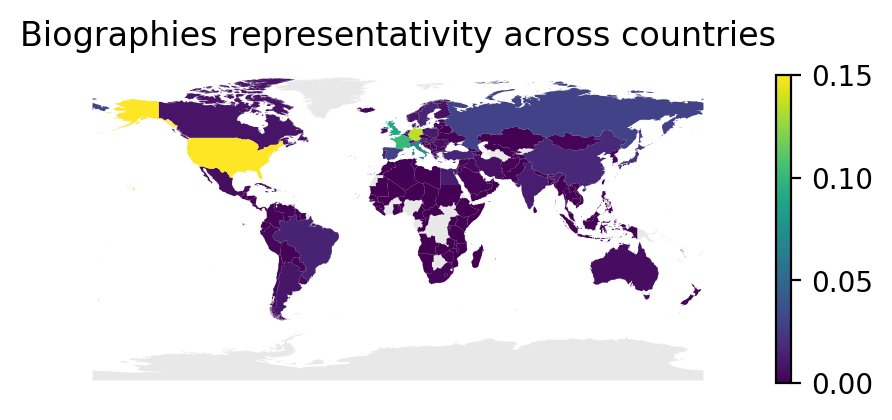

In [47]:
import geodatasets, geopandas
import numpy as np
import matplotlib.pyplot as plt
# geopandas.datasets.available

world_raw = geopandas.read_file("../../popularity_data/World_Countries/World_Countries.shp")
world_raw.rename(columns={'COUNTRY':'bplace_country'}, inplace=True)
world_raw.head()

to_plot = df[(df['year']==2022)].groupby(['year','bplace_country'])['slug'].nunique().reset_index()
world = world_raw.merge(to_plot)
world['v_log'] = world['slug']/world['slug'].sum()
# world['v_log'] = np.log(world['slug'])
# world['v_log'] =  np.square(-np.log(world['slug']*2))

fig, ax = plt.subplots(figsize = (4.5,8), dpi=200, tight_layout=True)

ax1 = world_raw.to_crs(epsg=4326).plot(ax=ax, color='lightgrey', alpha=0.5)
world.to_crs(epsg=4326).plot(column = 'v_log', ax=ax1, vmin=0.0, vmax=0.15, cmap = 'viridis',
            legend = True, legend_kwds={'shrink': 0.2}, 
            markersize = 10)
ax.set_title('Biographies representativity across countries')
ax.axis('off')


(-198.0, 198.0, -98.68117980957031, 92.30477600097656)

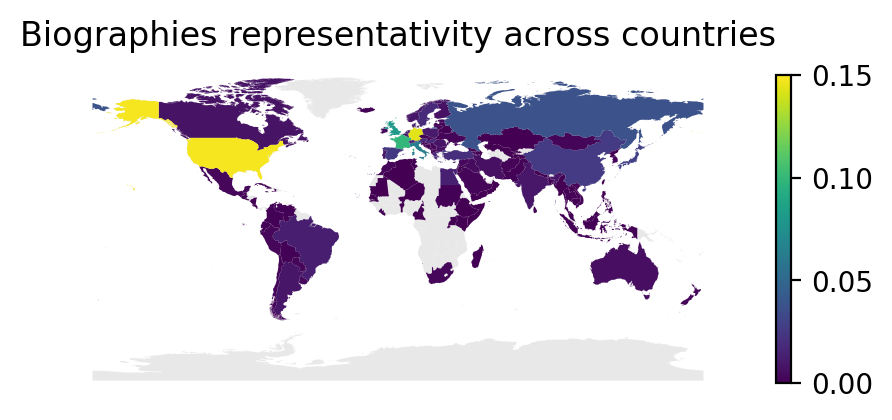

In [48]:
import geodatasets, geopandas
import numpy as np
import matplotlib.pyplot as plt
# geopandas.datasets.available

world_raw = geopandas.read_file("../../popularity_data/World_Countries/World_Countries.shp")
world_raw.rename(columns={'COUNTRY':'bplace_country'}, inplace=True)
world_raw.head()

to_plot = df[(df['locality']=='High locality') & (df['year']==2022)].groupby(['year','bplace_country'])['slug'].nunique().reset_index()
world = world_raw.merge(to_plot)
world['v_log'] = world['slug']/world['slug'].sum()
# world['v_log'] = np.log(world['slug'])
# world['v_log'] =  np.square(-np.log(world['slug']*2))

fig, ax = plt.subplots(figsize = (4.5,8), dpi=200, tight_layout=True)

ax1 = world_raw.to_crs(epsg=4326).plot(ax=ax, color='lightgrey', alpha=0.5)
world.to_crs(epsg=4326).plot(column = 'v_log', ax=ax1, vmin=0.0, vmax=0.15, cmap = 'viridis',
            legend = True, legend_kwds={'shrink': 0.2}, 
            markersize = 10)
ax.set_title('Biographies representativity across countries')
ax.axis('off')


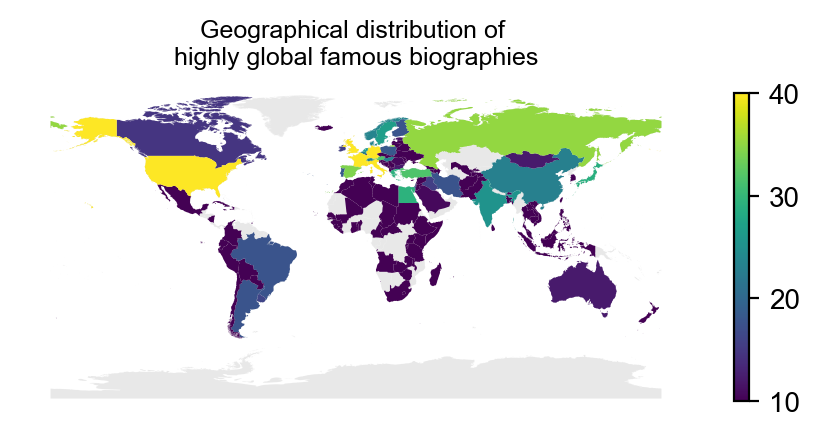

In [62]:
import geodatasets, geopandas
import numpy as np
import matplotlib.pyplot as plt
# geopandas.datasets.available
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Arial"
world_raw = geopandas.read_file("../../popularity_data/World_Countries/World_Countries.shp")
world_raw.rename(columns={'COUNTRY':'bplace_country'}, inplace=True)
world_raw.head()

to_plot = df[(df['globality']=='High globality') & (df['year']==2022)].groupby(['year','bplace_country'])['slug'].nunique().reset_index()
world = world_raw.merge(to_plot)
world  = world[world['slug']>0]
world['v_log'] = world['slug']/world['slug'].sum()
world['v_log'] = np.log(world['slug'])
world['v_log'] =  np.square(-np.log(world['slug']*2))

fig, ax = plt.subplots(figsize = (4.5,8), dpi=200, tight_layout=True)
# vmin=0.0, vmax=0.15,
ax1 = world_raw.to_crs(epsg=4326).plot(ax=ax, color='lightgrey', alpha=0.5)
world.to_crs(epsg=4326).plot(column = 'v_log', ax=ax1, vmin=10, vmax=40, cmap = 'viridis',
            legend = True, legend_kwds={'shrink': 0.2}, 
            markersize = 10)
ax.set_title('Geographical distribution of \nhighly global famous biographies', fontsize=9)
ax.axis('off')
plt.savefig('intensity_map_global.svg')
plt.savefig('intensity_map_global.png')

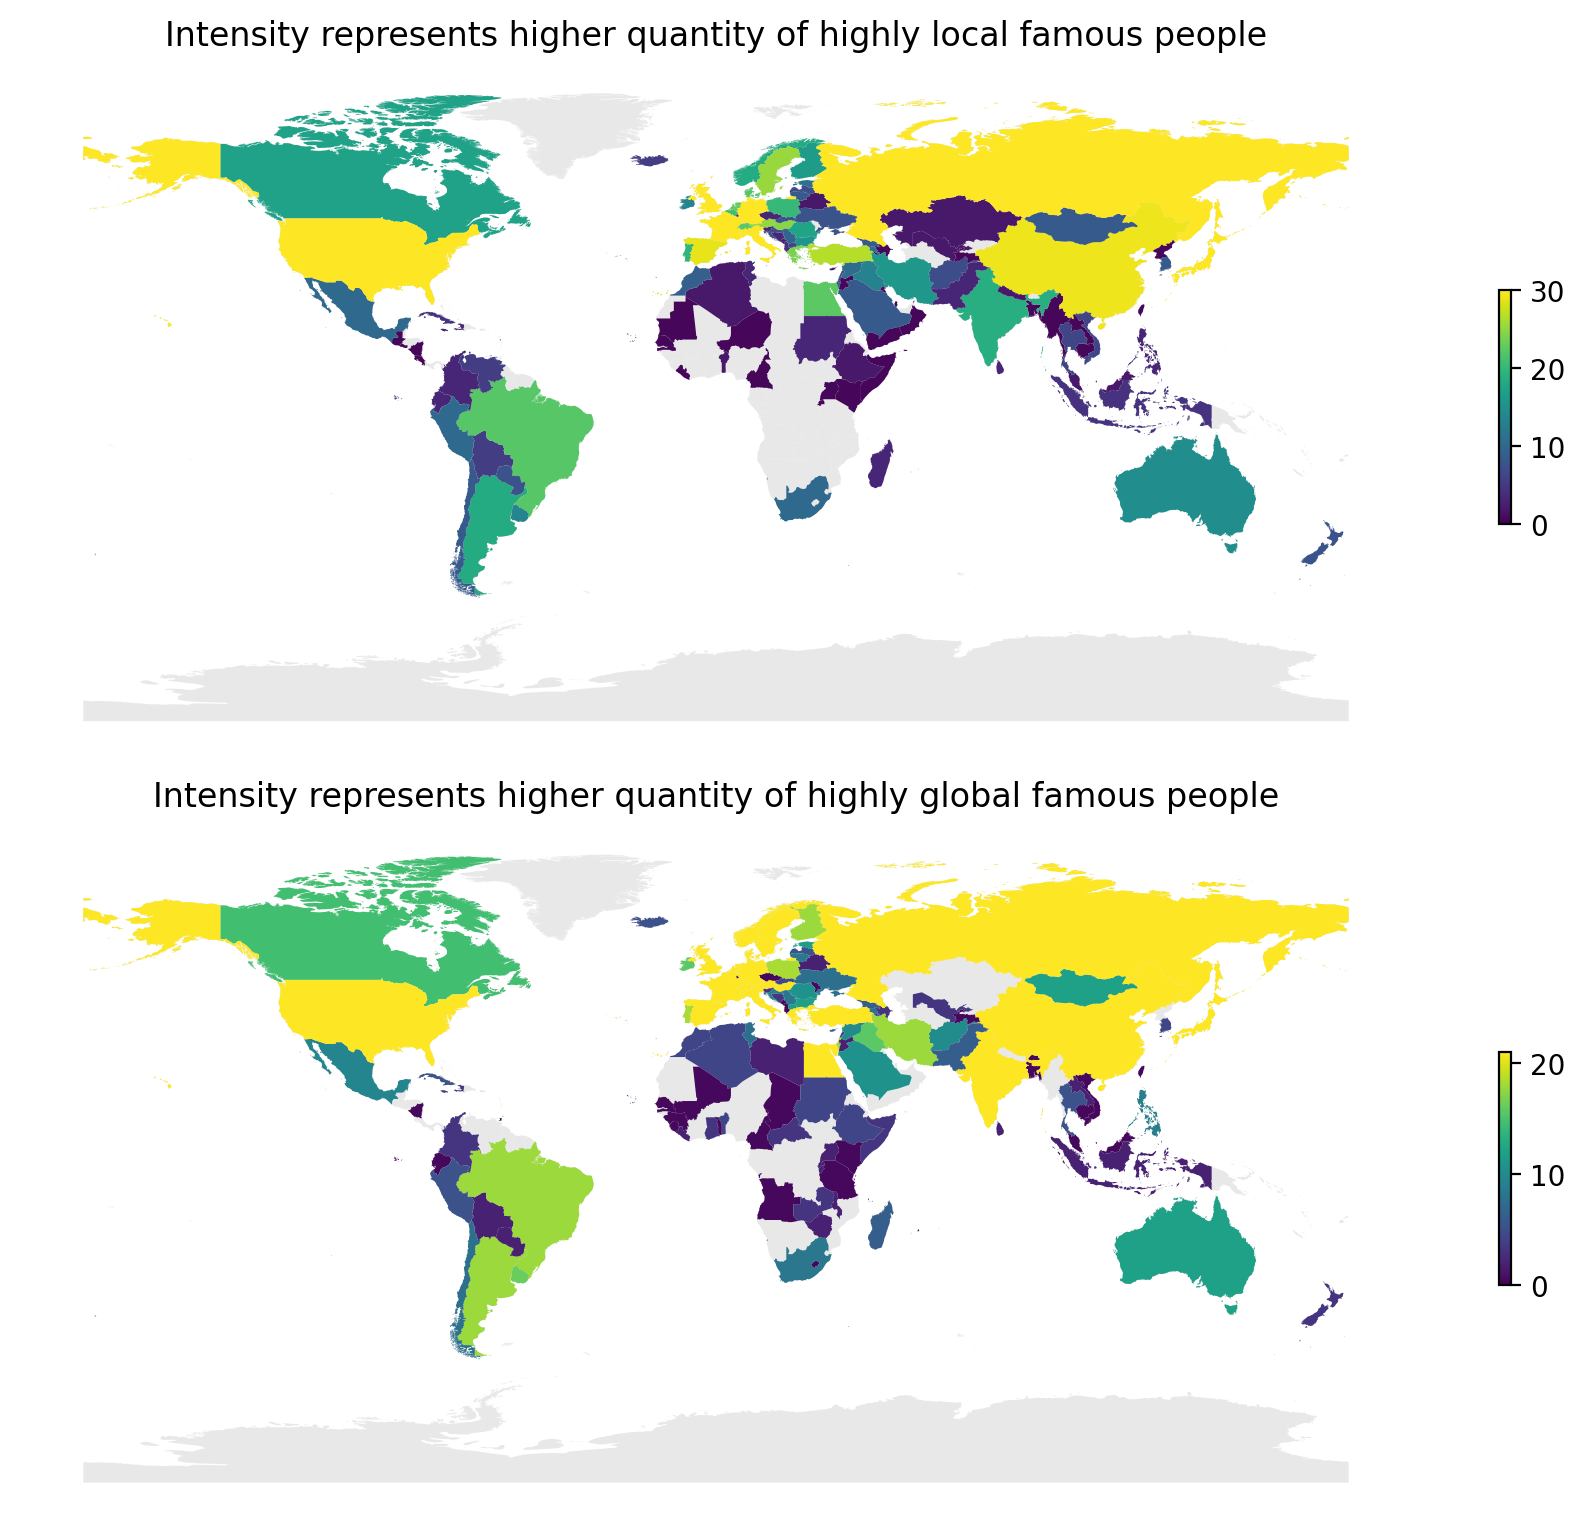

In [50]:
import geodatasets, geopandas
import numpy as np
import matplotlib.pyplot as plt
# geopandas.datasets.available

world_raw = geopandas.read_file("../../popularity_data/World_Countries/World_Countries.shp")
world_raw.rename(columns={'COUNTRY':'bplace_country'}, inplace=True)
world_raw.head()

to_plot = df[(df['locality']=='High locality') & (df['year']==2022)].groupby(['year','bplace_country'])['slug'].nunique().reset_index()
world = world_raw.merge(to_plot)

world['v_log'] = np.log(world['slug'])
world['v_log'] =  np.square(-np.log(world['slug']*2))

fig, ax = plt.subplots(nrows=2, figsize = (9,8), dpi=200, tight_layout=True)
ax1 = world_raw.to_crs(epsg=4326).plot(ax=ax[0], color='lightgrey', alpha=0.5)
world.to_crs(epsg=4326).plot(column = 'v_log', ax=ax1, vmin=0, vmax=30, cmap = 'viridis',
            legend = True, legend_kwds={'shrink': 0.3}, 
            markersize = 10)
ax[0].set_title('Intensity represents higher quantity of highly local famous people')
ax[0].axis('off')

to_plot = df[(df['globality']=='High globality') & (df['year']==2022)].groupby(['year','bplace_country'])['slug'].nunique().reset_index()

world = world_raw.merge(to_plot)
world['v_log'] = np.log(world['slug'])
world['v_log'] =  np.square(-np.log(world['slug']*2))

ax1 = world_raw.to_crs(epsg=4326).plot(ax=ax[1], color='lightgrey', alpha=0.5)
world.to_crs(epsg=4326).plot(column = 'v_log', ax=ax1, vmin=0, vmax=21,cmap = 'viridis',
            legend = True, legend_kwds={'shrink': 0.3}, 
            markersize = 10)
ax[1].set_title('Intensity represents higher quantity of highly global famous people')
ax[1].axis('off')

plt.savefig('intensity_map_local_global.svg')
# plt.savefig('intensity_map_local_global.pdf')